## GAN (QuantGAN-style, TCN + WGAN-GP) — Results Summary

Architecture: TCN-based Generator/Discriminator, WGAN-GP loss, minibatch-stddev 
diversity fix, 150 epochs, noise_dim=8, N_CRITIC=2.

Pillar 1 (Statistical Fidelity):
- Wasserstein distance: 0.0666
- KS statistic: 0.0326
- ACF: near-identical decay pattern to real data across lags 0-10, 
  strongest match at lag 1 (-0.085 real vs -0.083 synthetic)

Known limitation: earlier run showed mode collapse (fixed via minibatch-stddev); 
current model may still slightly underestimate tail extremes vs real data.

In [1]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

train = np.load("../../data/processed/train_windows.npy")   # (5200, 30)
test = np.load("../../data/processed/test_windows.npy")     # (1278, 30)

# add channel dim: (5200, 30) -> (5200, 30, 1)
train = train[..., None].astype(np.float32)

train_tensor = torch.from_numpy(train)
train_loader = DataLoader(TensorDataset(train_tensor), batch_size=64, shuffle=True)

print(train_tensor.shape)  # should show torch.Size([5200, 30, 1])

torch.Size([5200, 30, 1])


In [13]:
import sys
sys.path.append(".")  # so train.ipynb can import from same folder

from train import train as train_gan

ImportError: cannot import name 'train' from 'train' (/Users/siyasinnarkar/SynFinBench/generators/gan/train.py)

In [15]:
class WrappedLoader:
    """train() expects batches of shape (batch, seq_len, 1) directly, not a tuple."""
    def __init__(self, loader):
        self.loader = loader
    def __iter__(self):
        for (batch,) in self.loader:
            yield batch

G, D = train_gan(WrappedLoader(train_loader))

NameError: name 'train_gan' is not defined

In [ ]:
import os
os.makedirs("outputs", exist_ok=True)
torch.save(G.state_dict(), "outputs/generator.pt")
torch.save(D.state_dict(), "outputs/discriminator.pt")
print("saved.")

saved.


In [ ]:
from train import generate_synthetic_paths

synthetic = generate_synthetic_paths(G, n_paths=5, seq_len=30)
print(synthetic.shape)   # should be (5, 30, 1)

(5, 30, 1)


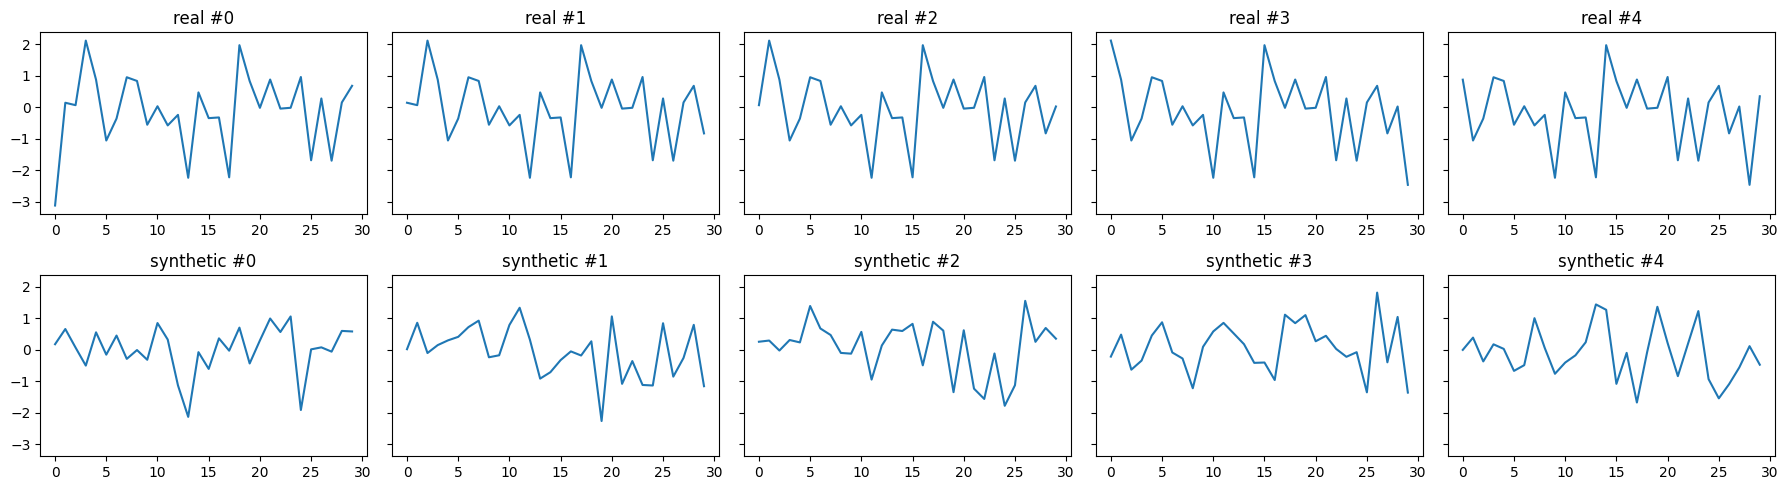

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(18, 5), sharey=True)

# top row: 5 real windows
for i in range(5):
    axes[0, i].plot(train[i, :, 0])
    axes[0, i].set_title(f"real #{i}")

# bottom row: 5 synthetic windows
for i in range(5):
    axes[1, i].plot(synthetic[i, :, 0])
    axes[1, i].set_title(f"synthetic #{i}")

plt.tight_layout()
plt.show()

In [ ]:
import torch
from model import Generator

NOISE_DIM = 3
SEQ_LEN = 30

G_final = Generator(noise_dim=NOISE_DIM)
G_final.load_state_dict(torch.load("outputs/generator_final.pt", map_location="cpu"))
G_final.eval()
print("loaded.")

loaded.


In [ ]:
def generate_synthetic_paths(G, n_paths, seq_len=SEQ_LEN, noise_dim=NOISE_DIM):
    with torch.no_grad():
        z = torch.randn(n_paths, seq_len, noise_dim)
        synthetic = G(z)
    return synthetic.numpy()

synthetic_final = generate_synthetic_paths(G_final, n_paths=5)
print(synthetic_final.shape)   # should be (5, 30, 1)

(5, 30, 1)


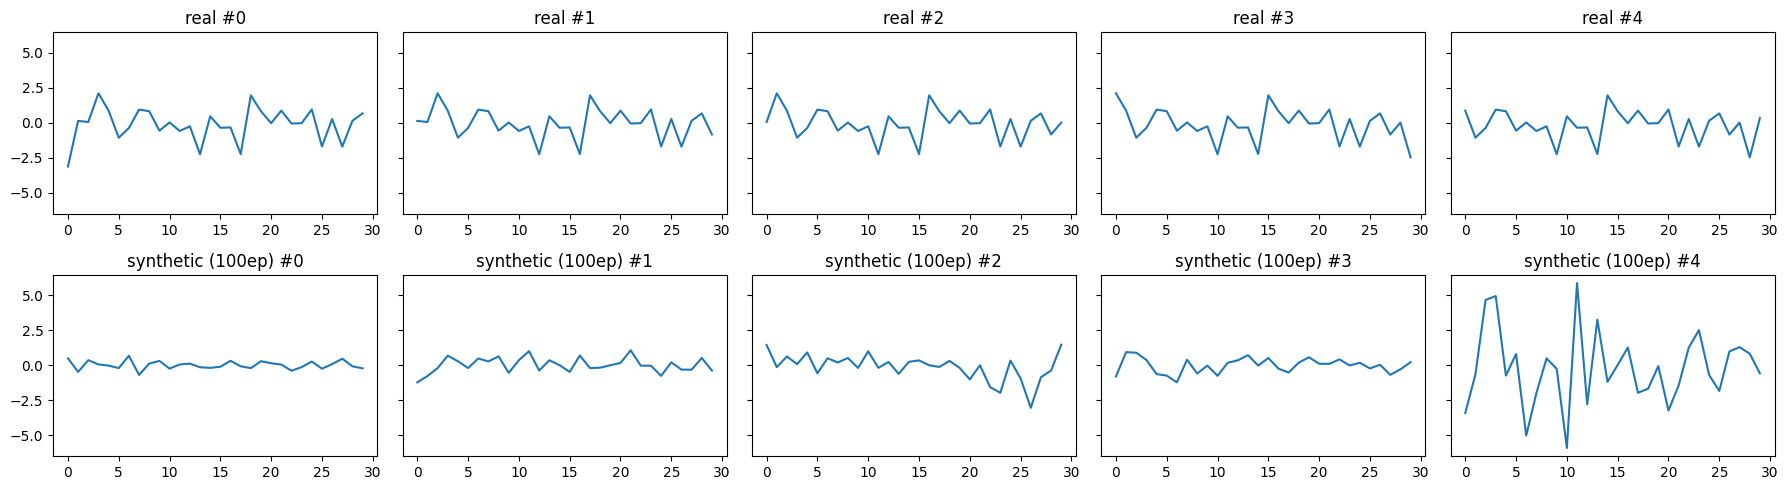

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(18, 5), sharey=True)

for i in range(5):
    axes[0, i].plot(train[i, :, 0])
    axes[0, i].set_title(f"real #{i}")

for i in range(5):
    axes[1, i].plot(synthetic_final[i, :, 0])
    axes[1, i].set_title(f"synthetic (100ep) #{i}")

plt.tight_layout()
plt.show()

In [ ]:
from model import Generator
import torch

def generate_synthetic_paths(G, n_paths, seq_len, noise_dim=8):
    with torch.no_grad():
        z = torch.randn(n_paths, seq_len, noise_dim)
        synthetic = G(z)
    return synthetic.numpy()

G_final = Generator(noise_dim=8)   # noise_dim=8 now, not 3!
G_final.load_state_dict(torch.load("outputs/generator_final.pt", map_location="cpu"))
G_final.eval()

synthetic_v2 = generate_synthetic_paths(G_final, n_paths=5, seq_len=30)
print(synthetic_v2.shape)

(5, 30, 1)


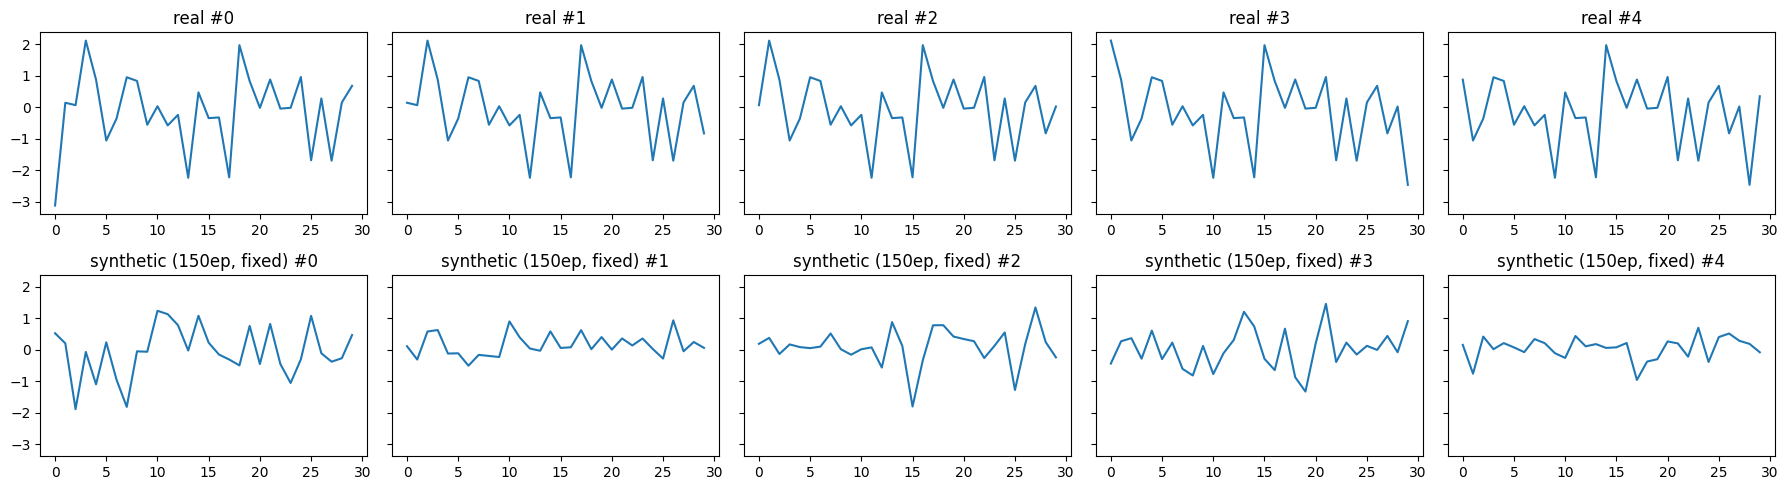

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(18, 5), sharey=True)

for i in range(5):
    axes[0, i].plot(train[i, :, 0])
    axes[0, i].set_title(f"real #{i}")

for i in range(5):
    axes[1, i].plot(synthetic_v2[i, :, 0])
    axes[1, i].set_title(f"synthetic (150ep, fixed) #{i}")

plt.tight_layout()
plt.show()


In [ ]:
synthetic_eval = generate_synthetic_paths(G_final, n_paths=1000, seq_len=30)
print(synthetic_eval.shape)

(1000, 30, 1)


In [ ]:
from scipy.stats import wasserstein_distance, ks_2samp

real_flat = train[:, :, 0].flatten()
synthetic_flat = synthetic_eval[:, :, 0].flatten()

w_dist = wasserstein_distance(real_flat, synthetic_flat)
ks_stat, ks_pvalue = ks_2samp(real_flat, synthetic_flat)

print(f"Wasserstein distance: {w_dist:.4f}")
print(f"KS statistic: {ks_stat:.4f}  (p-value: {ks_pvalue:.4f})")

Wasserstein distance: 0.0666
KS statistic: 0.0326  (p-value: 0.0000)


In [ ]:
from statsmodels.tsa.stattools import acf
import numpy as np

def avg_acf(data, nlags=10):
    acfs = []
    for i in range(data.shape[0]):
        acfs.append(acf(data[i, :, 0], nlags=nlags, fft=True))
    return np.mean(acfs, axis=0)

real_acf = avg_acf(train)
synthetic_acf = avg_acf(synthetic_eval)

print("Real ACF:      ", np.round(real_acf, 3))
print("Synthetic ACF: ", np.round(synthetic_acf, 3))

Real ACF:       [ 1.    -0.085 -0.044 -0.03  -0.032 -0.046 -0.035 -0.016 -0.021 -0.023
 -0.014]
Synthetic ACF:  [ 1.    -0.083 -0.061 -0.044 -0.035 -0.029 -0.023 -0.021 -0.024 -0.026
 -0.002]


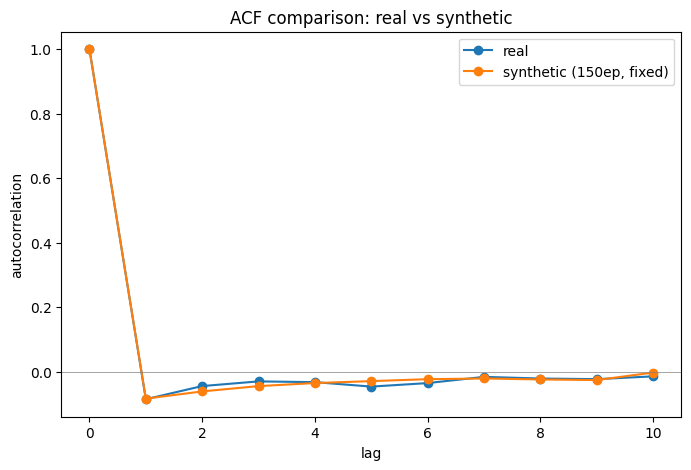

In [12]:
import matplotlib.pyplot as plt

lags = np.arange(len(real_acf))
plt.figure(figsize=(8, 5))
plt.plot(lags, real_acf, marker='o', label='real')
plt.plot(lags, synthetic_acf, marker='o', label='synthetic (150ep, fixed)')
plt.axhline(0, color='gray', linewidth=0.5)
plt.xlabel('lag')
plt.ylabel('autocorrelation')
plt.legend()
plt.title('ACF comparison: real vs synthetic')
plt.show()

In [16]:
import os

# Generate synthetic samples matching the real train set size,
# so downstream evaluation (e.g. TSTR) can do a like-for-like comparison
n_train_samples = train.shape[0]   # 5200, matches train_windows.npy

synthetic_output = generate_synthetic_paths(G_final, n_paths=n_train_samples, seq_len=30)
synthetic_output = synthetic_output[:, :, 0]   # drop the channel dim -> (5200, 30), matches train_windows.npy shape

print(synthetic_output.shape)   # should print (5200, 30)

os.makedirs("outputs", exist_ok=True)
np.save("outputs/synthetic_windows.npy", synthetic_output)
print("saved to outputs/synthetic_windows.npy")

(5200, 30)
saved to outputs/synthetic_windows.npy
